In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 51.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 84.4 MB/s eta 0:00:00:00:0100:01


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pennylane as qml
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt



# Quantum Circuit Definition with Angle Encoding and Parameterized Gates
def create_quantum_circuit(qubits):
    dev = qml.device('default.qubit', wires=qubits)

    @qml.qnode(dev)
    def circuit(input_data, params):
        # Ensure inputs are of correct length
        if len(input_data) != qubits:
            input_data = input_data[:qubits]  # Truncate if too long
            if len(input_data) < qubits:  # Pad if too short
                input_data = np.pad(input_data, (0, qubits - len(input_data)))


        if len(params) != qubits:
            params = np.random.rand(qubits)

        # Encode classical data into quantum state using angle encoding
        for i in range(qubits):
            qml.RY(input_data[i], wires=i)  # Apply Ry gates to input_data

        # Apply parameterized quantum gates to enhance the encoded state
        for i in range(qubits):
            qml.RX(params[i], wires=i)  # Apply Rx gate

        for i in range(qubits):
            qml.RZ(params[i] / 2, wires=i)  # Apply Rz gate

        return qml.probs(wires=range(qubits))  # Probabilities for each qubit

    return circuit

# Quantum Layer: This layer will scale the filters of a classical Conv2D
class QuantumConv2DLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, qubits=4):
        super(QuantumConv2DLayer, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.qubits = qubits

        # Define quantum circuit
        self.circuit = create_quantum_circuit(qubits=qubits)

        # Learnable parameters for the quantum circuit
        self.param = nn.Parameter(torch.randn(self.qubits))

        # Initialize Conv2D layer with proper dimensions
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=kernel_size//2
        )

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        # Extract features from the input tensor to feed into quantum circuit
        # We'll take the average of each channel as a simple feature
        features = torch.mean(x, dim=[2, 3])  # Average across spatial dimensions
        features = features.mean(dim=0)  # Average across batch dimension

        # Ensure we have the right number of features for our quantum circuit
        features_trimmed = features[:self.qubits] if len(features) > self.qubits else features
        if len(features_trimmed) < self.qubits:
            # Pad with zeros if we don't have enough features
            padding = torch.zeros(self.qubits - len(features_trimmed), device=x.device)
            features_trimmed = torch.cat([features_trimmed, padding])

        features_np = features_trimmed.cpu().detach().numpy()

        params = self.param.detach().cpu().numpy()

        # Run the quantum circuit
        result = self.circuit(features_np, params)

        # Convert result to tensor and reshape for scaling
        result_tensor = torch.tensor(result, dtype=torch.float32, device=x.device)
        quantum_scale = result_tensor.mean()  # Use mean of quantum result as scale factor

        # Apply the standard convolution with weights scaled by quantum result
        # First, save the original weights
        original_weight = self.conv.weight.data.clone()

        # Scale the weights
        self.conv.weight.data = original_weight * quantum_scale

        # Apply the convolution
        output = self.conv(x)

        self.conv.weight.data = original_weight

        return output

# Building the Model
class QuantumCNN(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), num_classes=10, qubits=8):
        super(QuantumCNN, self).__init__()

        # First Conv2D Layer
        self.conv1 = nn.Conv2d(in_channels=input_shape[2], out_channels=64, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.5)

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(64, 64, kernel_size=4, padding=1)
        self.dropout2 = nn.Dropout(0.25)

        # QuantumConv2D Layer (parameterized quantum circuits)
        self.qconv = QuantumConv2DLayer(in_channels=64, out_channels=64, kernel_size=3, qubits=qubits)

        # Calculate the size of flattened features after convolutions
        # After two max pooling with stride 2, the size is reduced to 1/4
        h_out = input_shape[0] // 4
        w_out = input_shape[1] // 4


        self.fc1 = nn.Linear(3136, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout1(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout2(x)

        # QuantumConv2D Layer
        x = self.qconv(x)

        # Flatten the output for fully connected layer
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Training Loop with Validation
def train(model, train_loader, val_loader, optimizer, criterion, epochs=10):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        # Training phase
        with tqdm(train_loader,desc=f'Epoch {epoch+1}/{epochs}',unit='batch') as tepoch:

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                tepoch.set_postfix(train_loss=train_loss/len(tepoch), accuracy=100.*correct/total)



        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss/len(train_loader):.4f}, Accuracy: {100.*correct/total:.2f}%")

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            with tqdm(val_loader, desc=f"Validation Epoch {epoch+1}", unit="batch") as vepoch:

                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
                    vepoch.set_postfix(val_loss=val_loss/len(vepoch), accuracy=100.*correct/total)


        print(f"Epoch {epoch+1} - Validation Loss: {val_loss/len(val_loader):.4f}, Accuracy: {100.*correct/total:.2f}%")

# Test function

def test(model, test_loader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Test Accuracy
    print(f"Test Accuracy: {100. * correct / total:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    print("Confusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))

    # F1 Score
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    print(f"\nF1 Score: {f1:.4f}")

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()



In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from collections import Counter

# Function to split the data based on provided class labels and data size
def create_data_splits(desired_classes, num_train_samples, num_test_samples, batch_size=32):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    # Load CIFAR-10 dataset
    full_train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    full_test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # Filter the data by the desired classes
    train_indices = [i for i, label in enumerate(full_train_data.targets) if label in desired_classes]
    test_indices = [i for i, label in enumerate(full_test_data.targets) if label in desired_classes]

    # Create subsets based on the filtered indices
    train_subset = Subset(full_train_data, train_indices)
    test_subset = Subset(full_test_data, test_indices)

    # Extract the labels for train and test datasets
    train_labels = [full_train_data.targets[i] for i in train_subset.indices]
    test_labels = [full_test_data.targets[i] for i in test_subset.indices]

    # Ensure proportional splitting based on class labels for train and test datasets
    def get_stratified_samples(labels, total_samples):
        # Get the number of samples to select for each class
        class_counts = Counter(labels)
        proportions = {class_label: count / len(labels) for class_label, count in class_counts.items()}

        # Calculate the number of samples per class for the required total_samples
        samples_per_class = {class_label: int(proportion * total_samples) for class_label, proportion in proportions.items()}

        selected_indices = []
        for class_label, count in samples_per_class.items():
            # Get indices for this class
            class_indices = [i for i, label in enumerate(labels) if label == class_label]
            # Select the required number of samples
            selected_indices.extend(np.random.choice(class_indices, count, replace=False))

        return selected_indices

    # Get the indices for training and testing data based on the required size
    train_sample_indices = get_stratified_samples(train_labels, num_train_samples)
    test_sample_indices = get_stratified_samples(test_labels, num_test_samples)

    # Create new subsets with the selected samples
    train_dataset = Subset(train_subset, train_sample_indices)
    test_dataset = Subset(test_subset, test_sample_indices)

    # Split the train dataset further into training and validation using Stratified Sampling
    train_labels_selected = [train_labels[i] for i in train_sample_indices]
    sss_train = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)  # 80% train, 20% validation
    train_idx, val_idx = next(sss_train.split(np.zeros(len(train_labels_selected)), train_labels_selected))

    val_dataset = Subset(train_dataset, val_idx)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# Example usage
desired_classes = [0, 1, 2, 3, 4,5,6,7,8,9]  # Classes you want to use
num_train_samples = 50000  # Total number of samples to use for training
num_test_samples = 8000  # Total number of samples to use for testing

# Get the data loaders
train_loader, val_loader, test_loader = create_data_splits(desired_classes, num_train_samples, num_test_samples, batch_size=32)

print("Training data loader size:", len(train_loader.dataset))
print("Validation data loader size:", len(val_loader.dataset))
print("Test data loader size:", len(test_loader.dataset))


Files already downloaded and verified
Files already downloaded and verified
Training data loader size: 50000
Validation data loader size: 10000
Test data loader size: 8000


In [ ]:
model = QuantumCNN(input_shape=(32, 32, 3), num_classes=10, qubits=8)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


batch_size = 32

train(model, train_loader, val_loader, optimizer, criterion, epochs=50)


Epoch 1/50:   0%|          | 0/1563 [00:25<?, ?batch/s, accuracy=41.6, train_loss=1.59]   


Epoch 1/50 - Train Loss: 1.5900, Accuracy: 41.57%


Validation Epoch 1:   0%|          | 0/313 [00:04<?, ?batch/s, accuracy=53.2, val_loss=1.3]    


Epoch 1 - Validation Loss: 1.2972, Accuracy: 53.21%


Epoch 2/50:   0%|          | 0/1563 [00:24<?, ?batch/s, accuracy=55.7, train_loss=1.24]    


...

Epoch 49 - Validation Loss: 0.0332, Accuracy: 99.01%


Epoch 50/50:   0%|          | 0/1563 [00:23<?, ?batch/s, accuracy=94.9, train_loss=0.145]   


Epoch 50/50 - Train Loss: 0.1454, Accuracy: 94.88%


Validation Epoch 50:   0%|          | 0/313 [00:03<?, ?batch/s, accuracy=99.4, val_loss=0.0212]  

Epoch 50 - Validation Loss: 0.0212, Accuracy: 99.38%


Test Accuracy: 76.54%
Confusion Matrix:
[[619  10  38   8  24   5   8   3  58  27]
 [ 12 696   6   5   2   3   8   3  27  38]
 [ 46   1 546  47  53  35  37  19  15   1]
 [ 22   3  64 446  54 127  41  23  16   4]
 [ 11   1  52  51 603  20  24  30   6   2]
 [ 10   2  39 141  26 530  13  26  11   2]
 [  4   3  34  49  34  12 655   3   3   3]
 [  9   4  23  25  51  30   2 641   6   9]
 [ 26  14   7   7   9   3   1   1 713  19]
 [ 19  42   3  12   6   3   8   9  24 674]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       800
           1       0.90      0.87      0.88       800
           2       0.67      0.68      0.68       800
           3       0.56      0.56      0.56       800
           4       0.70      0.75      0.73       800
           5       0.69      0.66      0.68       800
           6       0.82      0.82      0.82       800
           7       0.85      0.80      0.82       800
           8      

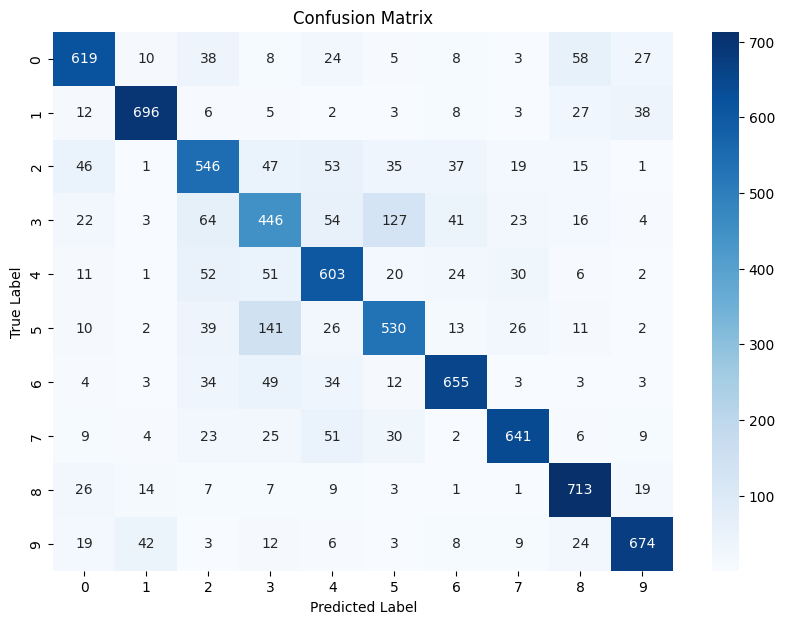

In [ ]:
# Test the model
test(model, test_loader)